# 06 — Model Monitoring: Population Stability Index (PSI)

## Why This Notebook Exists

A credit model is trained on one population but scores future applicants whose characteristics drift over time (economic cycles, product mix, marketing changes). If the incoming population drifts far enough from the training population, the model's risk estimates degrade silently. **Population Stability Index (PSI)** is the banking industry's standard early-warning metric for this drift.

PSI compares the distribution of a variable in a **reference** window (here, the earliest loan vintages) against a **current** window (the newest vintages):

$$\text{PSI} = \sum_i (\text{actual}_i - \text{expected}_i) \times \ln\frac{\text{actual}_i}{\text{expected}_i}$$

| PSI | Interpretation |
|---|---|
| < 0.10 | Stable — no action |
| 0.10 – 0.25 | Moderate shift — investigate |
| > 0.25 | Significant shift — recalibrate / retrain |

A 2025 result shows PSI is mathematically the same construct as the Information Value (IV) used for feature selection in Notebook 03 — the same divergence, computed between two time windows instead of between good/bad outcomes.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config as C
from src import data as D
from src import monitoring as M
from src.features import clean_frame, split_X_y
sns.set_style("whitegrid")

df = clean_frame(D.load_resolved(n=C.TRAIN_SAMPLE))
print("Vintages:", sorted(df["issue_year"].dropna().unique().astype(int)))

Vintages: [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]


## 1. Reference vs Current Windows

We split by loan vintage: the **earliest** issue years are the reference (what the model was effectively trained on) and the **latest** years are the current production population.

In [2]:
years = sorted(df["issue_year"].dropna().unique())
cut = years[len(years) // 2]
reference = df[df["issue_year"] < cut]
current = df[df["issue_year"] >= cut]
print(f"Reference vintages (< {int(cut)}): {len(reference):,} loans")
print(f"Current vintages  (>= {int(cut)}): {len(current):,} loans")

Reference vintages (< 2013): 11,007 loans
Current vintages  (>= 2013): 138,993 loans


## 2. Per-Feature PSI

,feature,psi,band
0,dti,0.1661,moderate shift
1,open_acc,0.0974,stable
2,inq_last_6mths,0.0686,stable
3,loan_amnt,0.0676,stable
4,revol_util,0.0514,stable
5,emp_length_num,0.0457,stable
6,annual_inc,0.0446,stable
7,total_acc,0.0363,stable
8,term_months,0.0037,stable


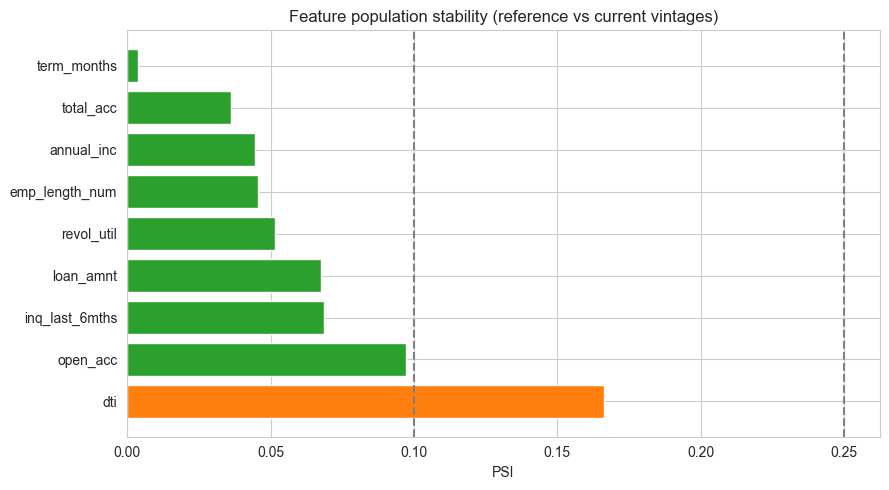

In [3]:
feature_cols = ["loan_amnt", "annual_inc", "dti", "revol_util", "open_acc",
                "total_acc", "inq_last_6mths", "emp_length_num", "term_months"]
psi_tbl = M.psi_report(reference, current, feature_cols)
display(psi_tbl)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["tab:green" if v < 0.10 else "tab:orange" if v < 0.25 else "tab:red"
          for v in psi_tbl["psi"]]
ax.barh(psi_tbl["feature"], psi_tbl["psi"], color=colors)
for thr in (0.10, 0.25):
    ax.axvline(thr, ls="--", color="grey")
ax.set_xlabel("PSI"); ax.set_title("Feature population stability (reference vs current vintages)")
plt.tight_layout(); plt.show()

**Reading the chart:** green bars (PSI < 0.10) are stable; orange (0.10–0.25) warrants investigation; red (> 0.25) signals a population shift large enough to undermine the model. Features tied to credit appetite and loan structure typically drift most across vintages as Lending Club changed its product mix and underwriting over time.

## 3. Score PSI — Drift in the Model Output

Beyond individual features, the most direct monitoring signal is drift in the **PD score distribution** itself. If the score distribution shifts, the approval mix and expected losses change even if no single feature looks alarming.

PD score PSI (reference vs current): 0.0152  -> stable


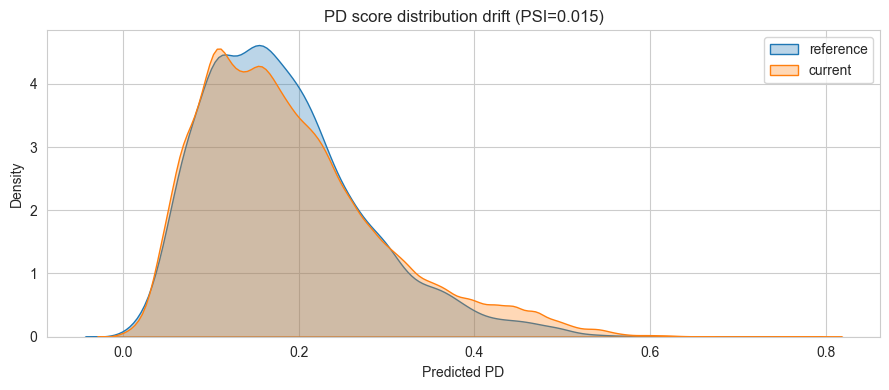

Saved reports/monitoring_psi.json


In [4]:
pd_model = __import__("joblib").load(C.MODELS_DIR / "pd_model.pkl")
Xref, _ = split_X_y(reference)
Xcur, _ = split_X_y(current)
score_ref = pd_model.predict_proba(Xref)[:, 1]
score_cur = pd_model.predict_proba(Xcur)[:, 1]
score_psi = M.psi(score_ref, score_cur)
print(f"PD score PSI (reference vs current): {score_psi:.4f}  -> {M.psi_band(score_psi)}")

fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(score_ref, label="reference", ax=ax, fill=True, alpha=0.3)
sns.kdeplot(score_cur, label="current", ax=ax, fill=True, alpha=0.3)
ax.set_xlabel("Predicted PD"); ax.set_title(f"PD score distribution drift (PSI={score_psi:.3f})")
ax.legend(); plt.tight_layout(); plt.show()

out = {"score_psi": float(score_psi), "score_psi_band": M.psi_band(score_psi),
       "feature_psi": psi_tbl.set_index("feature")["psi"].round(4).to_dict()}
(C.REPORTS_DIR / "monitoring_psi.json").write_text(json.dumps(out, indent=2))
print("Saved reports/monitoring_psi.json")

## 4. Monitoring Takeaway

PSI gives a lender an objective, regulator-recognized trigger for model review. In production this would run on a schedule (monthly/quarterly): per-feature PSI localizes *which* inputs drifted, and score PSI tells you whether that drift actually moved the model's risk ranking enough to warrant recalibration or a full retrain. Because PSI = IV mathematically, the same code that built the scorecard in Notebook 03 powers the monitoring here.